SECTION 1

In [ ]:
import pandas as pd
import numpy as np

from tqdm import tqdm

from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

SECTION 2
Load Modeling Dataset

(Load the frozen dataset created in Notebook 06)

In [ ]:
ratings_df = pd.read_csv(
    "netflix_modeling_data.csv"
)

In [ ]:
ratings_df["date"].astype(str).str.len().value_counts()

,count
date,
10,2000000


In [ ]:
bad_dates = ratings_df[
    ratings_df["date"].astype(str).str.len() != 10
]

bad_dates

,user_id,movie_id,rating,date


In [ ]:
ratings_df = ratings_df[
    ratings_df["date"].astype(str).str.len() == 10
]

In [ ]:
ratings_df["date"] = pd.to_datetime(
    ratings_df["date"]
)

In [ ]:
ratings_df["date"] = pd.to_datetime(
    ratings_df["date"]
)

In [ ]:
ratings_df.shape

(2000000, 4)

SECTION 3
Per-User Temporal Split

(Train on older ratings and test on newer ratings for each user)

In [ ]:
# Sort User Histories
ratings_df = ratings_df.sort_values(
    ["user_id", "date"]
)

In [ ]:
train_parts = []
test_parts = []

for _, group in tqdm(
    ratings_df.groupby("user_id")
):

    if len(group) < 2:
        train_parts.append(group)
        continue

    split_idx = int(
        len(group) * 0.8
    )

    train_parts.append(
        group.iloc[:split_idx]
    )

    test_parts.append(
        group.iloc[split_idx:]
    )

100%|██████████| 358375/358375 [00:54<00:00, 6600.19it/s]


In [ ]:
ratings_df.shape

(2000000, 4)

In [ ]:
ratings_df["user_id"].nunique()

358375

In [ ]:
ratings_df.groupby("user_id").size().describe()

,0
count,358375.000000
mean,5.580746
std,6.797435
min,1.000000
25%,1.000000
50%,3.000000
75%,7.000000
max,378.000000


In [ ]:
ratings_df.groupby("user_id").size().head(20)

,0
user_id,
6,10
7,21
8,3
10,5
25,1
33,1
42,6
79,20
83,1


In [ ]:
print("Train parts:", len(train_parts))
print("Test parts:", len(test_parts))

Train parts: 358375
Test parts: 266936


In [ ]:
print(type(train_parts))
print(type(test_parts))

<class 'list'>
<class 'list'>


In [ ]:
test_parts[:5]

[        user_id  movie_id  rating       date
 234793        6      1220       4 2004-12-07
 891275        6      7643       3 2004-12-14,
          user_id  movie_id  rating       date
 1312327        7     11490       4 2005-05-23
 1394506        7      9320       5 2005-05-23
 1532386        7     16452       3 2005-05-23
 1650509        7     17494       4 2005-05-23
 1965094        7     14702       5 2005-05-23,
          user_id  movie_id  rating       date
 1631966        8     14712       4 2005-08-25,
         user_id  movie_id  rating       date
 467942       10      1905       5 2005-10-25,
         user_id  movie_id  rating       date
 127117       42      1734       4 2005-03-01
 940300       42      6475       4 2005-09-06]

In [ ]:
# Combine
train_df = pd.concat(
    train_parts
)

test_df = pd.concat(
    test_parts
)

In [ ]:
# Check Shapes
print(
    "Train Shape:",
    train_df.shape
)

print(
    "Test Shape:",
    test_df.shape
)

Train Shape: (1506935, 4)
Test Shape: (493065, 4)


SECTION 4
Coverage Verification

(Ensure test users exist in train set)

In [ ]:
train_users = set(
    train_df["user_id"]
)

test_users = set(
    test_df["user_id"]
)

unseen_users = (
    test_users -
    train_users
)

print(
    "Unseen Users:",
    len(unseen_users)
)

Unseen Users: 0


In [ ]:
train_movies = set(
    train_df["movie_id"]
)

test_movies = set(
    test_df["movie_id"]
)

unseen_movies = (
    test_movies -
    train_movies
)

print(
    "Unseen Movies:",
    len(unseen_movies)
)

Unseen Movies: 817


SECTION 5
RMSE Function

(Evaluation metric)

In [ ]:
def rmse(
    actual,
    predicted
):

    return np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

SECTION 6
Build Surprise Dataset

(Prepare data for recommendation models)

In [ ]:
!pip install scikit-surprise -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 37.1 MB/s eta 0:00:00


In [ ]:
from surprise import Dataset
from surprise import Reader
from surprise import KNNBasic
from surprise import SVD

In [ ]:
reader = Reader(
    rating_scale=(1,5)
)

In [ ]:
surprise_data = Dataset.load_from_df(
    train_df[
        [
            "user_id",
            "movie_id",
            "rating"
        ]
    ],
    reader
)

In [ ]:
trainset = (
    surprise_data
    .build_full_trainset()
)

SECTION 7
Item-Based CF

(Neighborhood recommendation model)

In [ ]:
sim_options = {
    "name": "cosine",
    "user_based": False
}

item_cf = KNNBasic(
    sim_options=sim_options
)

item_cf.fit(
    trainset
)

Computing the cosine similarity matrix...
Done computing similarity matrix.


SECTION 8
Item-CF Evaluation

(Evaluate rating prediction accuracy)

In [ ]:
item_predictions = []

for row in tqdm(
    test_df.itertuples(),
    total=len(test_df)
):

    pred = item_cf.predict(
        row.user_id,
        row.movie_id
    )

    item_predictions.append(
        pred.est
    )

100%|██████████| 493065/493065 [00:08<00:00, 58891.23it/s]


In [ ]:
item_rmse = rmse(
    test_df["rating"],
    item_predictions
)

print(
    "Item-CF RMSE:",
    round(
        item_rmse,
        4
    )
)

Item-CF RMSE: 1.1544


SECTION 9
SVD Model

(Latent factor recommendation model)

In [ ]:
svd_model = SVD(
    n_factors=50,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

In [ ]:
svd_model.fit(
    trainset
)

SECTION 10
SVD Evaluation

(Evaluate latent factor model)

In [ ]:
svd_predictions = []

for row in tqdm(
    test_df.itertuples(),
    total=len(test_df)
):

    pred = svd_model.predict(
        row.user_id,
        row.movie_id
    )

    svd_predictions.append(
        pred.est
    )

100%|██████████| 493065/493065 [00:04<00:00, 104447.17it/s]


In [ ]:
svd_rmse = rmse(
    test_df["rating"],
    svd_predictions
)

print(
    "SVD RMSE:",
    round(
        svd_rmse,
        4
    )
)

SVD RMSE: 0.9735


SECTION 11
Model Comparison

(Compare recommendation approaches)

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Item-CF",
        "SVD"
    ],

    "RMSE": [
        item_rmse,
        svd_rmse
    ]
})

comparison

,Model,RMSE
0,Item-CF,1.154415
1,SVD,0.973522


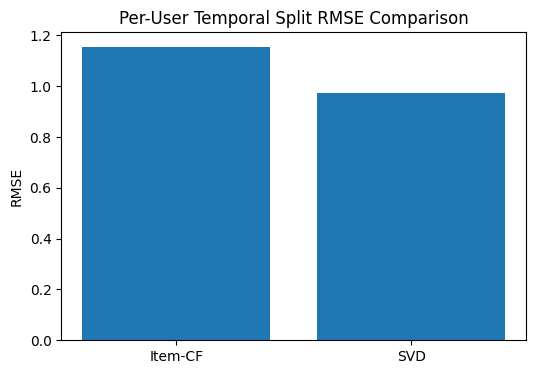

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title(
    "Per-User Temporal Split RMSE Comparison"
)

plt.ylabel(
    "RMSE"
)

plt.show()

In [ ]:
train_df.to_csv(
    "train_per_user_temporal.csv",
    index=False
)

test_df.to_csv(
    "test_per_user_temporal.csv",
    index=False
)